In [1]:
import numpy as np
import pandas as pd

def aggregate_de_results(
    df,
    group_col="symbol",
    strata_col="level_0",
    lfc_col="log2FoldChange",
    se_col="lfcSE",
    basemean_col="baseMean",
):
    """
    Aggregate DE results across strata (e.g. level_0) for each gene/symbol
    using empirical Bayes-style inverse-variance weighting.

    Returns:
        DataFrame with:
            symbol
            log2FoldChange   # EB pooled estimate
            lfcSE            # pooled SE
            baseMean         # mean baseMean across strata
            n_strata
    """

    def _aggregate_group(g):
        # remove invalid rows
        g = g[
            np.isfinite(g[lfc_col]) &
            np.isfinite(g[se_col]) &
            (g[se_col] > 0)
        ].copy()

        if len(g) == 0:
            return pd.Series({
                "log2FoldChange": np.nan,
                "lfcSE": np.nan,
                "baseMean": np.nan,
                "n_strata": 0,
            })

        # observed effects + variances
        y = g[lfc_col].values
        v = g[se_col].values ** 2

        # ---- empirical Bayes random-effects shrinkage ----
        # DerSimonian-Laird estimate for between-study variance tau^2

        w_fixed = 1 / v
        mu_fixed = np.sum(w_fixed * y) / np.sum(w_fixed)

        Q = np.sum(w_fixed * (y - mu_fixed) ** 2)
        df_Q = len(y) - 1

        C = np.sum(w_fixed) - (np.sum(w_fixed**2) / np.sum(w_fixed))

        tau2 = max(0, (Q - df_Q) / C) if C > 0 else 0

        # EB/random-effects weights
        w = 1 / (v + tau2)

        mu = np.sum(w * y) / np.sum(w)

        # pooled standard error
        se = np.sqrt(1 / np.sum(w))

        return pd.Series({
            "log2FoldChange": mu,
            "lfcSE": se,
            "baseMean": g[basemean_col].mean(),
            "n_strata": len(g),
        })

    out = (
        df.groupby(group_col, observed=True)
        .apply(_aggregate_group)
        .reset_index()
    )

    return out

In [2]:
from tqdm import tqdm
import meta_analysis
from meta_analysis.go import GeneOntologyLibraries
from meta_analysis.ot import UnbalancedSinkhorn, IterativeProportionalFitting
from meta_analysis.meta import MetaAnalysis

/home/jhaberbe/Projects/Personal/MAY2026/meta-analysis/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
GO_LIBRARIES = {
    "GO_BP": "GO_Biological_Process_2025",
    # "GO_MF": "GO_Molecular_Function_2025",
    # "GO_CC": "GO_Cellular_Component_2025",
    # "Reactome": "Reactome_Pathways_2024",
    # "SynGO": "SynGO_2024",
    # "WikiPathways": "WikiPathways_2024_Human",
    # "LINCS_Chem_Pert": "LINCS_L1000_Chem_Pert_Consensus_Sigs",
    # "LINCS_CRISPR": "LINCS_L1000_CRISPR_KO_Consensus_Sigs"
}

GO_TERMS = {
    k: GeneOntologyLibraries().pull_assignment_matrix(v)
    for k, v in tqdm(GO_LIBRARIES.items())
}

100%|██████████| 1/1 [00:06<00:00,  6.26s/it]


In [4]:
grey_matter_regions = [
    'Gyrus Frontalis Medius',
    'Insula',
    'Cerebellum GM',
    'Gyrus Temporalis Medius',
    'Gyrus Parietalis',
    'Anterior Cingulate Cortex',
    'Posterior Cingulate Cortex',
    'Occipital Cortex ',
    'Prefrontal Cortex '
]

white_matter_regions = [
    'Frontal WM',
    'Cerebellum WM',
    'Temporal WM',
    'Corpus Callosum',
    'Parietal WM',
    'Occipital WM'
]

In [6]:
import pathlib
import pandas as pd

output_path = pathlib.Path("/home/jhaberbe/Projects/Personal/MAY2026/meta-analysis/output")
cell_type_libraries = pathlib.Path("/home/jhaberbe/Projects/Personal/MAY2026/cell-deconvolution/output/")

output_path.mkdir(parents=True, exist_ok=True)

for go_name, go_matrix in GO_TERMS.items():

    go_dir = output_path / go_name
    go_dir.mkdir(parents=True, exist_ok=True)

    for ct_path in cell_type_libraries.glob("*/"):

        ct_dir = go_dir / ct_path.stem
        ct_dir.mkdir(parents=True, exist_ok=True)

        df = pd.concat({
            f.stem: pd.read_csv(f, index_col=0)
                    .drop_duplicates(subset=["symbol"])
                    .set_index("symbol")
            for f in ct_path.glob("*.csv")
        }).reset_index().query("level_0 in @grey_matter_regions")

        df = aggregate_de_results(df).set_index("symbol")

        GO_TO_USE = go_name
        GO = go_matrix

        genes_available = df.index.intersection(GO.index)
        go_terms_available = GO.columns[GO.loc[genes_available].sum(axis=0).gt(0)]

        df = df.loc[genes_available]

        balanced_matrix = UnbalancedSinkhorn().get_balanced_matrix(
            GO.loc[genes_available, go_terms_available],
            tolerance=1e-12
        )

        table = pd.DataFrame(
            MetaAnalysis().generate_meta_estimate(
                df.loc[genes_available],
                balanced_matrix.loc[genes_available, go_terms_available]
            )
        )

        table.to_csv(ct_dir / f"{go_name}_{ct_path.stem}.csv")
        balanced_matrix.to_csv(ct_dir / f"{go_name}_{ct_path.stem}_balanced.csv")
        df.to_csv(ct_dir / f"{go_name}_{ct_path.stem}_deseq.csv")

Unbalanced Sinkhorn:   2%|▏         | 21/1000 [00:00<00:00, 1247.76it/s]


NameError: name 'normalized_standard_error' is not defined

In [41]:
import pandas as pd

cell_type = "serotonergic neuron"

output_path = pathlib.Path(
    f"/home/jhaberbe/Projects/Personal/MAY2026/meta-analysis/output/GO_BP/{cell_type}"
)

table = pd.read_csv(output_path / f"{GO_TO_USE}_{cell_type}.csv", index_col=0)
balanced_matrix = pd.read_csv(output_path / f"{GO_TO_USE}_{cell_type}_balanced.csv", index_col=0)
df = pd.read_csv(output_path / f"{GO_TO_USE}_{cell_type}_deseq.csv", index_col=0)

In [43]:
import plotly.express as px

table["symbol"] = table.index

px.scatter(
    table.query("n_eff >= 2"),
    x="shrunken_estimate",
    y="log10p_eb",
    size="weights",
    hover_name="symbol",
    hover_data=["n_eff", "shrunken_estimate"],
    width=1000,
    height=750,
    size_max=100
)

In [44]:
table.query("n_eff >= 2").sort_values(by="log10p_eb").tail(20)

,weights,n_eff,naive_estimate,naive_standard_error,shrunken_estimate,shrunken_se,z_naive,z_eb,p_naive,p_eb,log10p_naive,log10p_eb,B,full_dataset_mean,full_dataset_standard_error,symbol
Vascular Associated Smooth Muscle Cell Differentiation (GO:0035886),5.608811,2.109580,0.292813,0.173931,0.254970,0.163108,1.683502,1.563196,0.092278,0.118007,1.034902,0.928094,0.879424,-0.021038,0.220643,Vascular Associated Smooth Muscle Cell Differe...
Regulation of Leukocyte Cell-Cell Adhesion (GO:1903037),16.280849,2.359763,0.247933,0.148132,0.223603,0.141274,1.673725,1.582763,0.094185,0.113476,1.026020,0.945098,0.909545,-0.021038,0.220643,Regulation of Leukocyte Cell-Cell Adhesion (GO...
Negative Regulation of Membrane Potential (GO:0045837),190.823415,2.036771,-0.156173,0.096995,-0.150647,0.094991,1.610126,1.585916,0.107370,0.112758,0.969115,0.947851,0.959105,-0.021038,0.220643,Negative Regulation of Membrane Potential (GO:...
Negative Regulation of Hydrogen Peroxide-Mediated Programmed Cell Death (GO:1901299),240.778435,2.194216,0.301930,0.173667,0.263091,0.162891,1.738552,1.615139,0.082114,0.106281,1.085585,0.973546,0.879745,-0.021038,0.220643,Negative Regulation of Hydrogen Peroxide-Media...
Positive Regulation of Protein K63-linked Ubiquitination (GO:1902523),152.837783,3.649265,-0.170999,0.103957,-0.163997,0.101501,1.644892,1.615708,0.099992,0.106157,1.000034,0.974050,0.953307,-0.021038,0.220643,Positive Regulation of Protein K63-linked Ubiq...
Positive Regulation of Adaptive Immune Response (GO:0002821),50.202188,2.870093,0.282757,0.157686,0.251989,0.149488,1.793159,1.685677,0.072948,0.091858,1.136990,1.036883,0.898720,-0.021038,0.220643,Positive Regulation of Adaptive Immune Respons...
Negative Regulation of Microglial Cell Activation (GO:1903979),66.468488,2.441508,-0.251563,0.142769,-0.232068,0.136599,1.762034,1.698908,0.078064,0.089337,1.107552,1.048971,0.915433,-0.021038,0.220643,Negative Regulation of Microglial Cell Activat...
Galactose Catabolic Process (GO:0019388),61.241512,2.030440,-0.258501,0.145333,-0.237755,0.138840,1.778677,1.712443,0.075293,0.086815,1.123247,1.061405,0.912635,-0.021038,0.220643,Galactose Catabolic Process (GO:0019388)
Regulation of Circadian Sleep/Wake Cycle (GO:0042749),9.743262,2.859367,0.370133,0.195344,0.312457,0.180368,1.894777,1.732324,0.058122,0.083216,1.235660,1.079794,0.852555,-0.021038,0.220643,Regulation of Circadian Sleep/Wake Cycle (GO:0...
Regulation of T-helper 17 Cell Lineage Commitment (GO:2000328),15.439756,3.679621,0.309383,0.160024,0.275023,0.151475,1.933354,1.815627,0.053193,0.069428,1.274149,1.158468,0.896010,-0.021038,0.220643,Regulation of T-helper 17 Cell Lineage Commitm...


/home/jhaberbe/Projects/Personal/MAY2026/meta-analysis/meta_analysis/pl.py:206: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.96])


(          gene      L2FC        SE  lower_ci  upper_ci  pct_contribution
 PPTC7    PPTC7  0.358421  0.091675  0.178738  0.538104          0.032094
 VPS13C  VPS13C  0.478036  0.086490  0.308515  0.647556          0.034048
 TSC2      TSC2  0.150832  0.048368  0.056031  0.245633          0.155233
 RBX1      RBX1  0.062520  0.044920 -0.025524  0.150564          0.227475
 PINK1    PINK1  0.461693  0.041784  0.379796  0.543590          0.551150,
 <Figure size 1100x500 with 4 Axes>,
 array([[<Axes: xlabel='log2 fold change'>, <Axes: xlabel='Contribution'>],
        [<Axes: xlabel='meta log2 fold change'>, <Axes: >]], dtype=object))

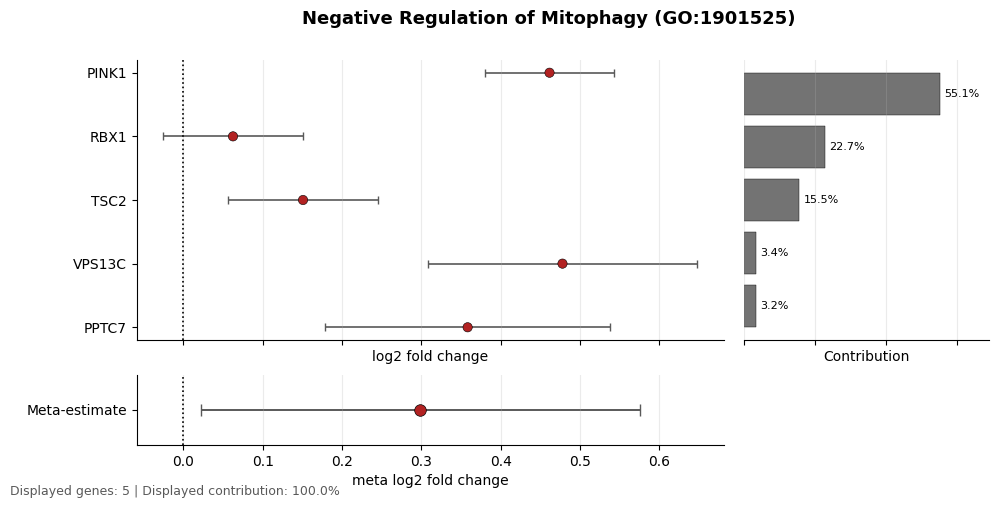

In [46]:
from meta_analysis.pl import ForestPlotter

###### SOMETHING HORRIBLE IS GOING ON HERE
ForestPlotter(df, (balanced_matrix.T * df["baseMean"]).T, table) \
    .plot_term("Negative Regulation of Mitophagy (GO:1901525)", cutoff=1)